# Diseño y Preparación de Datos NoSQL del CNIT 2025 
## Caso de estudio: Vías de Comunicación (camino_l)

## 1. Introducción y Fuente de Datos
La presente práctica tiene como propósito desarrollar el diseño y preparación de una base de datos NoSQL a partir de información geoespacial contenida en el Conjunto Nacional de Información Topográfica (CNIT) escala 1:50 000, 2025. 

El trabajo se enfoca en la temática de Vías de Comunicación, utilizando como caso piloto la capa `camino_l`, con el fin de implementar un flujo completo de exploración, limpieza, transformación y carga de datos geoespaciales en una base de datos orientada a documentos. 

La estructura propuesta busca ser escalable para incorporar posteriormente el resto de las clases temáticas del CNIT 2025.
### 1.1 Objetivo de la práctica 
Diseñar y preparar una base de datos NoSQL utilizando información geoespacial del CNIT 2025, aplicando procesos de exploración, limpieza, transformación y carga de datos que permitan almacenar y consultar objetos geográficos de manera eficiente.
### 1.2 Descripción del Conjunto Nacional de Información Topográfica (CNIT 2025)
El Conjunto Nacional de Información Topográfica (CNIT) escala 1:50 000, 2025, es un conjunto de datos geoespaciales elaborado por el Instituto Nacional de Estadística y Geografía (INEGI), cuyo objetivo es representar de manera estructurada los elementos físicos y culturales presentes en el territorio nacional. 

La información se encuentra organizada mediante objetos geográficos clasificados por temas y subtemas, incorporando geometrías de tipo punto, línea y área, además de sus respectivos atributos descriptivos. 

Para este proyecto, los datos se encuentran almacenados en formato GeoPackage (GPKG), lo que facilita su consulta y procesamiento mediante herramientas de análisis geoespacial.
### 1.3 Justificación de la selección de Vías de Comunicación 
La temática de Vías de Comunicación fue seleccionada como caso de estudio debido a la relevancia que tienen estos elementos para la representación cartográfica y el análisis territorial. 

Asimismo, esta temática incluye distintos tipos de objetos lineales, permitiendo evaluar la capacidad de un modelo NoSQL para almacenar y gestionar información geoespacial de manera flexible. 

Entre los objetos considerados dentro de esta temática se encuentran caminos, carreteras, vialidades, vías férreas, puentes y túneles.
### 1.4 Alcance del caso de estudio
Debido al volumen de información contenido en el CNIT 2025, se trabajará inicialmente con la capa `camino_l` como caso piloto. 

La estructura diseñada permitirá incorporar posteriormente otras capas pertenecientes a la temática de Vías de Comunicación sin necesidad de modificar el modelo de datos propuesto. 

El alcance de esta práctica comprende: 
- Exploración de los datos geoespaciales. 
- Construcción del diccionario de datos. 
- Diseño de un modelo NoSQL orientado a documentos. 
- Limpieza y validación de información. 
- Transformación de geometrías a formato GeoJSON. 
- Carga inicial en MongoDB. 
- Consultas básicas de validación. 
### 1.5 Descripción de la capa piloto: camino_l
La capa `camino_l` representa elementos lineales correspondientes a caminos identificados dentro del territorio nacional. 

De acuerdo con el Diccionario de Datos Topográficos (DDT), esta clase incluye distintas categorías funcionales, entre las que se encuentran: 
- Brecha 
- Terracería 
- Vereda 

Estas categorías permiten evaluar distintos escenarios de clasificación y almacenamiento dentro de una base de datos NoSQL, manteniendo una estructura homogénea para la representación de objetos geográficos lineales.

## 2. Exploración del GeoPackage
El primer paso consiste en realizar una exploración inicial del archivo GeoPackage correspondiente al CNIT 2025. Esta etapa permite identificar las capas disponibles, conocer su tipo de geometría y cuantificar el número de registros almacenados en cada una. 
### 2.1 Carga de librerías


In [4]:
# Manejo de datos espaciales
import geopandas as gpd
import pandas as pd
import pyogrio
from pathlib import Path

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


### 2.2 Conexión al GeoPackage
Se define la ruta del archivo GeoPackage que contiene el Conjunto Nacional de Información Topográfica (CNIT 2025). > Sustituir la ruta por la ubicación real del archivo en el equipo.

In [5]:
ruta_gpkg = r"D:\EXTRACCION TOPOGRAFICA\2025\CNIT2025\RESPALDO\06-10-2025\continuo2025.gpkg" 
Path(ruta_gpkg).exists()

True

### 2.3 Inventario de capas disponibles
Se obtiene el listado completo de capas contenidas en el GeoPackage.

In [6]:
import pyogrio

capas = pyogrio.list_layers(ruta_gpkg)

df_capas = pd.DataFrame(
    capas,
    columns=["Capa", "Geometría"]
)

print(f"Total de capas encontradas: {len(df_capas)}")

df_capas

Total de capas encontradas: 95


,Capa,Geometría
0,acueducto_l,LineString
1,aerodromo_a,Polygon
2,area_publica_a,Polygon
3,banco_mater_p,Point
4,banco_nivel_p,Point
...,...,...
90,zona_a,MultiPolygon
91,manzana_a,Polygon
92,cuerpo_agua_a,MultiPolygon
93,localidad_p,Point


### 2.4 Identificación del tipo de geometría por capa
La exploración inicial del GeoPackage permitió identificar que el CNIT 2025 contiene 95 capas geográficas distribuidas entre geometrías de tipo punto, línea y área. 

La información obtenida evidencia la naturaleza heterogénea del conjunto de datos y confirma la presencia de objetos geográficos representados mediante geometrías simples y multiparte. 

La tabla generada en el apartado anterior muestra para cada capa su respectivo tipo de geometría.

### 2.5 Conteo de registros por capa
Con el propósito de dimensionar el volumen de información contenido en cada capa, se contabiliza el número de registros geográficos almacenados dentro del GeoPackage. 

Esta información permitirá identificar las capas con mayor cantidad de entidades y seleccionar aquellas que serán consideradas para el desarrollo del modelo NoSQL.

In [ ]:
resumen_capas = []

for capa in df_capas["Capa"]:

    gdf = gpd.read_file(
        ruta_gpkg,
        layer=capa
    )

    resumen_capas.append({
        "Capa": capa,
        "Geometría": gdf.geom_type.iloc[0] if len(gdf) > 0 else None,
        "Registros": len(gdf)
    })

inventario = pd.DataFrame(resumen_capas)

inventario

,Capa,Geometría,Registros
0,acueducto_l,LineString,22220
1,aerodromo_a,Polygon,89
2,area_publica_a,Polygon,18069
3,banco_mater_p,Point,5047
4,banco_nivel_p,Point,70781
...,...,...,...
90,zona_a,MultiPolygon,2146
91,manzana_a,Polygon,2276412
92,cuerpo_agua_a,MultiPolygon,455913
93,localidad_p,Point,241592


In [8]:
#Guardar resultados del inventario
inventario.to_csv(
    "inventario_capas.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Inventario exportado")


Inventario exportado


Se ordenan las capas de acuerdo con el número de registros para identificar aquellas con mayor volumen de información.

In [9]:
inventario.sort_values(
    by="Registros",
    ascending=False
).head(20)

,Capa,Geometría,Registros
20,edificacion_p,Point,4132640
16,curva_nivel_l,LineString,3033618
14,corriente_ag_l,LineString,2427848
91,manzana_a,Polygon,2276412
86,vialidad_l,LineString,2261035
6,camino_l,LineString,638594
92,cuerpo_agua_a,MultiPolygon,455913
5,bordo_l,LineString,360000
93,localidad_p,Point,241592
73,referencia_g_p,Point,132006


La distribución de registros por capa muestra una alta variabilidad en el volumen de información almacenada dentro del CNIT 2025.

Entre las capas con mayor cantidad de entidades destacan aquellas asociadas a la representación detallada del territorio y de los asentamientos humanos, lo que evidencia la complejidad y riqueza temática del conjunto de datos.

Este análisis permitió identificar el tamaño relativo de cada capa y orientar la selección de una temática piloto para el diseño inicial de la base de datos NoSQL.

### 2.6 Resumen de las capas de Vías de Comunicación
A partir del inventario general del GeoPackage se identifican las capas correspondientes a la temática de Vías de Comunicación. 

Estas capas constituyen el universo de información que podrá incorporarse progresivamente al modelo NoSQL diseñado para este proyecto. 

El presente trabajo se enfoca inicialmente en la capa `camino_l`, sin embargo, la estructura propuesta permitirá integrar posteriormente el resto de los objetos relacionados con la movilidad y conectividad territorial..

In [10]:
capas_vias = inventario[
    inventario["Capa"].str.contains(
        "camino|carretera|vialidad|via_ferrea|puente|tunel",
        case=False,
        regex=True
    )
]

capas_vias.sort_values(
    by="Registros",
    ascending=False
)

,Capa,Geometría,Registros
86,vialidad_l,LineString,2261035
6,camino_l,LineString,638594
9,carretera_l,LineString,39321
69,puente_l,LineString,29484
85,via_ferrea_l,LineString,603
83,tunel_l,LineString,515


## 3. Análisis y Diccionario de Datos de camino_l
### 3.1 Carga de la capa camino_l
Con el propósito de conocer la estructura detallada de la información, se carga la capa `camino_l`, correspondiente a los caminos representados dentro del Conjunto Nacional de Información Topográfica 2025. 

Esta capa constituye el caso de estudio seleccionado para el diseño del modelo NoSQL debido a la diversidad de categorías que representa y a su relevancia dentro de la temática de Vías de Comunicación.

In [11]:
gdf_camino = gpd.read_file(
    ruta_gpkg,
    layer="camino_l"
)

gdf_camino.head()

,id,nom_obj,codigo,calif_pos,tipo,clase_geo,geometry
0,326190921,Camino,3171.0,Definida,Brecha,Servicios e instalaciones,"LINESTRING (-100.56124 20.16551, -100.56095 20..."
1,327792345,Camino,3173.0,Definida,Terracería,Servicios e instalaciones,"LINESTRING (-96.64207 19.3143, -96.64254 19.31..."
2,34233237,Camino,3171.0,Definida,Brecha,Servicios e instalaciones,"LINESTRING (-92.82649 16.55708, -92.82617 16.5..."
3,328056650,Camino,3171.0,Definida,Brecha,Servicios e instalaciones,"LINESTRING (-100.1094 23.42868, -100.10951 23...."
4,328826646,Camino,3173.0,Definida,Terracería,Servicios e instalaciones,"LINESTRING (-97.00261 18.75018, -97.00257 18.7..."


### 3.2 Inspección de atributos 
Se identifican los atributos disponibles en la capa con el fin de conocer la información descriptiva asociada a cada entidad geográfica.

In [12]:
gdf_camino.columns.tolist()

['id', 'nom_obj', 'codigo', 'calif_pos', 'tipo', 'clase_geo', 'geometry']

### 3.3 Tipos de datos de los campos 


In [13]:
gdf_camino.dtypes

id              int32
nom_obj           str
codigo        float64
calif_pos         str
tipo              str
clase_geo         str
geometry     geometry
dtype: object

### 3.4 Estadísticas generales de la capa
Se obtiene un resumen general de la capa, incluyendo el número de registros, número de campos y tipo de geometría predominante.

In [14]:
print(f"Registros: {len(gdf_camino)}")
print(f"Campos: {len(gdf_camino.columns)}")

gdf_camino.geom_type.value_counts()

Registros: 638594
Campos: 7


LineString    638594
Name: count, dtype: int64

### 3.5 Identificación de dominios y categorías
Con el propósito de identificar los valores categóricos asociados a los caminos, se analizan los dominios contenidos en el atributo `tipo`. 

Este atributo permite distinguir las diferentes categorías de caminos representadas en el CNIT 2025 y constituye uno de los elementos principales para la organización y consulta de la información dentro del modelo NoSQL.

In [15]:
gdf_camino["tipo"].value_counts()

tipo
Brecha        392218
Vereda        159609
Terracería     86767
Name: count, dtype: int64

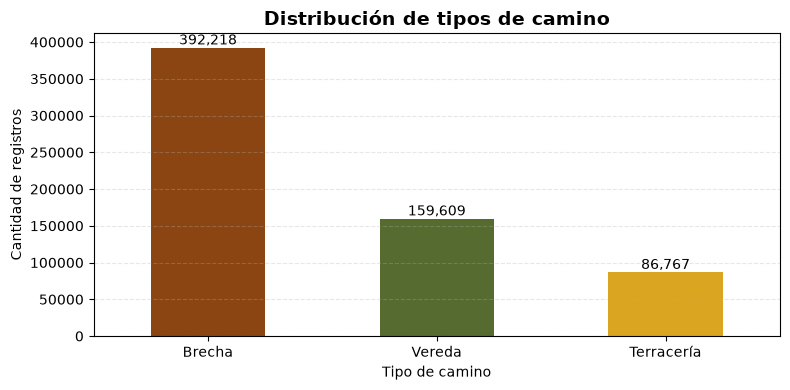

In [21]:
import matplotlib.pyplot as plt

ax = gdf_camino["tipo"].value_counts().plot(
    kind="bar",
    color=["saddlebrown", "darkolivegreen", "goldenrod"],
    figsize=(8, 4)
)

ax.set_title(
    "Distribución de tipos de camino",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Tipo de camino")
ax.set_ylabel("Cantidad de registros")

# Agregar etiquetas sobre cada barra
for barra in ax.patches:
    
    altura = barra.get_height()
    
    ax.annotate(
        f'{altura:,.0f}',
        (
            barra.get_x() + barra.get_width() / 2,
            altura
        ),
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

El análisis del atributo `tipo` permitió identificar tres categorías principales dentro de la capa `camino_l`: Brecha, Vereda y Terracería.

La categoría con mayor representación es Brecha, con 392,218 registros, lo que representa aproximadamente el 61.4% del total de caminos registrados en la capa. Por su parte, Vereda concentra 159,609 registros (25.0%) y Terracería 86,767 registros (13.6%).

Esta distribución evidencia el predominio de caminos de tipo Brecha dentro del conjunto de datos analizado, lo cual resulta consistente con la cobertura nacional del CNIT 2025 y la representación de vías de comunicación de menor jerarquía presentes en amplias zonas rurales del territorio.

Las categorías identificadas serán utilizadas como criterio de clasificación dentro del modelo NoSQL propuesto, permitiendo realizar consultas, filtros y análisis específicos por tipo de camino.

### 3.6 Construcción del diccionario de datos
A partir de la estructura física identificada en el GeoPackage y de las definiciones contenidas en el Diccionario de Datos Topográficos (DDT), se construyó el diccionario de datos de la capa `camino_l`. 

La siguiente tabla resume los atributos que conforman la capa y su función dentro del modelo propuesto.

In [16]:
diccionario = pd.DataFrame({
    "Campo": gdf_camino.columns,
    "Tipo de dato": [str(x) for x in gdf_camino.dtypes]
})

diccionario

,Campo,Tipo de dato
0,id,int32
1,nom_obj,str
2,codigo,float64
3,calif_pos,str
4,tipo,str
5,clase_geo,str
6,geometry,geometry


| Campo | Descripción |
|---------|---------|
| id | Identificador único del objeto geográfico |
| nom_obj | Nombre oficial del objeto geográfico |
| codigo | Código de clasificación del objeto |
| calif_pos | Calificación posicional del objeto |
| tipo | Categoría del camino (Brecha, Terracería, Vereda, entre otros) |
| clase_geo | Clase geográfica a la que pertenece el objeto |
| geometry | Geometría espacial almacenada en formato vectorial |

## 4. Diseño del Modelo NoSQL
### 4.1 Selección del gestor NoSQL

Para el desarrollo de esta práctica se seleccionó MongoDB como sistema gestor de bases de datos NoSQL.

MongoDB utiliza un modelo orientado a documentos basado en estructuras JSON, lo que facilita el almacenamiento de información geográfica con atributos heterogéneos y geometrías representadas en formato GeoJSON.

La flexibilidad de este enfoque resulta adecuada para el manejo de objetos geográficos del CNIT 2025, ya que permite incorporar nuevos atributos y clases temáticas sin requerir modificaciones estructurales complejas.

### 4.2 Diseño de la base de datos `cnit2025`
Se propone la creación de una base de datos denominada `cnit2025`, destinada a almacenar información geoespacial proveniente del Conjunto Nacional de Información Topográfica. 

La estructura está diseñada para permitir la incorporación progresiva de otras capas temáticas, manteniendo un esquema flexible que facilite futuras extensiones relacionadas con el análisis y priorización de objetos geográficos.

### 4.3 Diseño de la colección `vias_comunicacion` 
Se propone una colección denominada `vias_comunicacion`, destinada al almacenamiento de los objetos geográficos relacionados con la movilidad y conectividad territorial. 

Inicialmente se incorporarán los registros provenientes de la capa `camino_l`; sin embargo, la colección está diseñada para integrar posteriormente otras capas como carreteras, vialidades, puentes, túneles y vías férreas. 

La utilización de una colección única permite centralizar la información temática y simplificar las consultas posteriores.

### 4.4 Definición de atributos del documento 
La estructura documental propuesta conserva los atributos identificados en la capa `camino_l`, incorporando además la geometría en formato GeoJSON para facilitar su almacenamiento dentro de MongoDB. 

La definición detallada de los campos y sus tipos de dato fue presentada previamente en el diccionario de datos, por lo que en esta sección se enfatiza únicamente su incorporación al modelo documental.

### 4.5 Representación de geometrías en formato GeoJSON
Las geometrías almacenadas en el GeoPackage serán transformadas al estándar GeoJSON para facilitar su almacenamiento y consulta dentro de MongoDB. 

La utilización de GeoJSON permite conservar la estructura espacial original de los objetos geográficos y habilita futuras operaciones de consulta geoespacial.


In [23]:
gdf_camino.iloc[0].geometry.__geo_interface__

{'type': 'LineString',
 'coordinates': ((-100.5612421, 20.1655121),
  (-100.56094775, 20.16554285),
  (-100.5604702, 20.165589349999998),
  (-100.5601441, 20.1656862),
  (-100.55980485, 20.16566605),
  (-100.5596291, 20.16563895),
  (-100.55937435, 20.1655776),
  (-100.5590849, 20.16550595),
  (-100.55888935, 20.1655005))}

### 4.6 Documento JSON de ejemplo

La siguiente estructura muestra un ejemplo simplificado de cómo será almacenado un objeto geográfico de la capa `camino_l` dentro de la colección `vias_comunicacion`.

```json
{
  "id": 1,
  "nom_obj": "CAMINO",
  "codigo": "...",
  "calif_pos": "...",
  "tipo": "Brecha",
  "clase_geo": "Camino",
  "geometry": {
    "type": "LineString",
    "coordinates": [...]
  }
}
```

La estructura documental propuesta permite almacenar tanto los atributos descriptivos como la componente espacial de cada objeto geográfico dentro de una misma entidad documental.

Este diseño facilita la incorporación de nuevas capas pertenecientes a la temática de Vías de Comunicación y constituye la base para la carga inicial de información en MongoDB.

## 5. Limpieza de Datos 
### 5.1 Identificación de valores nulos 
La identificación de valores nulos constituye una etapa fundamental dentro del proceso de limpieza de datos, ya que permite detectar información faltante que pueda afectar el análisis posterior o la carga de información en la base de datos NoSQL. 

Para la capa `camino_l` se realiza una revisión de los atributos con el fin de identificar campos que presenten valores vacíos o ausentes.

In [26]:
nulos = (
    gdf_camino.isnull()
    .sum()
    .reset_index()
)

nulos.columns = [
    "Campo",
    "Valores nulos"
]

nulos

,Campo,Valores nulos
0,id,0
1,nom_obj,0
2,codigo,0
3,calif_pos,0
4,tipo,0
5,clase_geo,0
6,geometry,0


El análisis de valores nulos indica que todos los atributos de la capa `camino_l` presentan información completa, sin registros con datos faltantes.

Este resultado evidencia la consistencia y calidad de la información contenida en el CNIT 2025 para la capa analizada, por lo que no fue necesario aplicar procedimientos de imputación o eliminación de registros asociados a valores nulos.

### 5.2 Identificación de registros duplicados
Se realiza la búsqueda de registros duplicados con el objetivo de identificar posibles redundancias dentro del conjunto de datos. 

La presencia de registros duplicados podría generar inconsistencias en el almacenamiento y análisis posterior de la información. 

In [27]:
duplicados = gdf_camino.duplicated().sum()

print(f"Registros duplicados encontrados: {duplicados}")

Registros duplicados encontrados: 0


### 5.3 Validación de geometrías
Las geometrías se validan para verificar que su estructura espacial sea correcta y compatible con los procesos de transformación y almacenamiento en formato GeoJSON.

Esta validación resulta especialmente importante para garantizar la integridad de la información geográfica durante la carga en MongoDB.

In [28]:
geometrias_validas = gdf_camino.geometry.is_valid.sum()

geometrias_invalidas = (
    len(gdf_camino) - geometrias_validas
)

print(f"Geometrías válidas: {geometrias_validas:,}")
print(f"Geometrías inválidas: {geometrias_invalidas:,}")

Geometrías válidas: 638,594
Geometrías inválidas: 0


### 5.4 Homologación de valores categóricos
Se revisa el atributo `tipo` para verificar la consistencia en la escritura de las categorías existentes.

La homologación de valores categóricos permite evitar inconsistencias derivadas de diferencias en mayúsculas, minúsculas o variantes ortográficas.


In [29]:
gdf_camino["tipo"].unique()

<StringArray>
['Brecha', 'Terracería', 'Vereda']
Length: 3, dtype: str

### 5.5 Resultados de la limpieza
Los procedimientos de limpieza aplicados a la capa `camino_l` permitieron verificar la calidad y consistencia de la información antes de iniciar el proceso de transformación y preparación de datos.

Las principales observaciones obtenidas fueron:

- No se identificaron valores nulos en los atributos analizados.
- No se identificaron registros duplicados.
- Las geometrías fueron evaluadas para verificar su validez espacial.
- Las categorías del atributo `tipo` presentan una estructura homogénea y consistente.

En consecuencia, la capa `camino_l` se encuentra en condiciones adecuadas para continuar con las etapas de transformación y carga al modelo NoSQL propuesto.


## 6. Transformación y Preparación de Datos 
### 6.1 Selección de atributos para MongoDB
A partir del análisis realizado sobre la capa `camino_l`, se seleccionaron los atributos necesarios para conservar la información descriptiva y espacial requerida por el modelo documental propuesto.

Los campos seleccionados permiten mantener la trazabilidad con respecto a la fuente original, al mismo tiempo que facilitan su almacenamiento y consulta dentro de MongoDB.



In [30]:
atributos_mongo = [
    "id",
    "nom_obj",
    "codigo",
    "calif_pos",
    "tipo",
    "clase_geo",
    "geometry"
]

atributos_mongo

['id', 'nom_obj', 'codigo', 'calif_pos', 'tipo', 'clase_geo', 'geometry']

### 6.2 Conversión de geometrías a GeoJSON
Las geometrías contenidas en la capa `camino_l` se transforman al formato GeoJSON, estándar ampliamente utilizado para el intercambio y almacenamiento de información geoespacial en sistemas orientados a documentos.

In [31]:
gdf_camino["geometry"].iloc[0].__geo_interface__

{'type': 'LineString',
 'coordinates': ((-100.5612421, 20.1655121),
  (-100.56094775, 20.16554285),
  (-100.5604702, 20.165589349999998),
  (-100.5601441, 20.1656862),
  (-100.55980485, 20.16566605),
  (-100.5596291, 20.16563895),
  (-100.55937435, 20.1655776),
  (-100.5590849, 20.16550595),
  (-100.55888935, 20.1655005))}

### 6.3 Creación de la estructura documental
Se construye una estructura documental que integra tanto los atributos descriptivos como la geometría de cada objeto geográfico.

Esta estructura servirá como base para la generación de documentos compatibles con MongoDB.

In [32]:
registro_ejemplo = gdf_camino.iloc[0]

documento = {
    "id": registro_ejemplo["id"],
    "nom_obj": registro_ejemplo["nom_obj"],
    "codigo": registro_ejemplo["codigo"],
    "calif_pos": registro_ejemplo["calif_pos"],
    "tipo": registro_ejemplo["tipo"],
    "clase_geo": registro_ejemplo["clase_geo"],
    "geometry": registro_ejemplo["geometry"].__geo_interface__
}

documento

{'id': np.int32(326190921),
 'nom_obj': 'Camino',
 'codigo': np.float64(3171.0),
 'calif_pos': 'Definida',
 'tipo': 'Brecha',
 'clase_geo': 'Servicios e instalaciones',
 'geometry': {'type': 'LineString',
  'coordinates': ((-100.5612421, 20.1655121),
   (-100.56094775, 20.16554285),
   (-100.5604702, 20.165589349999998),
   (-100.5601441, 20.1656862),
   (-100.55980485, 20.16566605),
   (-100.5596291, 20.16563895),
   (-100.55937435, 20.1655776),
   (-100.5590849, 20.16550595),
   (-100.55888935, 20.1655005))}}

### 6.4 Generación de documentos JSON
A partir de los registros contenidos en la capa `camino_l`, se generan documentos con estructura JSON listos para su incorporación a una colección de MongoDB.

In [33]:
documentos_json = []

for _, fila in gdf_camino.head(100).iterrows():

    documentos_json.append({
        "id": fila["id"],
        "nom_obj": fila["nom_obj"],
        "codigo": fila["codigo"],
        "calif_pos": fila["calif_pos"],
        "tipo": fila["tipo"],
        "clase_geo": fila["clase_geo"],
        "geometry": fila["geometry"].__geo_interface__
    })

len(documentos_json)

100

### 6.5 Validación de los documentos generados
Se verifica que los documentos generados contengan la estructura esperada y que incorporen correctamente tanto los atributos descriptivos como la componente espacial en formato GeoJSON.

In [36]:
documentos_json[0]

{'id': 326190921,
 'nom_obj': 'Camino',
 'codigo': 3171.0,
 'calif_pos': 'Definida',
 'tipo': 'Brecha',
 'clase_geo': 'Servicios e instalaciones',
 'geometry': {'type': 'LineString',
  'coordinates': ((-100.5612421, 20.1655121),
   (-100.56094775, 20.16554285),
   (-100.5604702, 20.165589349999998),
   (-100.5601441, 20.1656862),
   (-100.55980485, 20.16566605),
   (-100.5596291, 20.16563895),
   (-100.55937435, 20.1655776),
   (-100.5590849, 20.16550595),
   (-100.55888935, 20.1655005))}}

## 7. Carga Inicial y Administración de la Base de Datos 
### 7.1 Preparación para la carga en MongoDB

Una vez generados los documentos JSON a partir de la capa `camino_l`, se preparó la estructura necesaria para su inserción en una base de datos MongoDB.

La base de datos propuesta se denomina `cnit2025` y contará inicialmente con una colección denominada `vias_comunicacion`, destinada al almacenamiento de objetos geográficos relacionados con la conectividad terrestre.

La estructura documental generada cumple con los requisitos necesarios para ser insertada directamente en MongoDB mediante el uso de la biblioteca PyMongo.

### 7.2 Creación de la base de datos cnit2025
La base de datos propuesta para almacenar la información geoespacial del CNIT 2025 se denomina `cnit2025`.

Esta base de datos fue diseñada para alojar inicialmente la temática de Vías de Comunicación, permitiendo la incorporación progresiva de otras clases geográficas contenidas en el Conjunto Nacional de Información Topográfica.

In [37]:
from pymongo import MongoClient

cliente = MongoClient(
    "mongodb://localhost:27017/"
)

db = cliente["cnit2025"]

db

Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'cnit2025')

### 7.3 Creación de la colección `vias_comunicacion`
Dentro de la base de datos `cnit2025` se propone una colección denominada `vias_comunicacion`.

Esta colección almacenará objetos geográficos correspondientes a caminos, carreteras, vialidades, túneles, puentes y vías férreas, manteniendo una estructura documental homogénea.

In [38]:
coleccion = db["vias_comunicacion"]

coleccion

Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True), 'cnit2025'), 'vias_comunicacion')

### 7.4 Inserción de documentos desde Python
Los documentos generados durante la etapa de preparación de datos pueden incorporarse a MongoDB mediante la operación `insert_many()`. Esta operación permite insertar múltiples documentos en una sola transacción.

In [ ]:
# Inserción propuesta

# coleccion.insert_many(documentos_json)


Durante las pruebas se preparó el código de inserción utilizando la biblioteca PyMongo. La ejecución de la operación no se completó debido a que el servicio MongoDB no se encontraba instalado ni disponible en el entorno de trabajo.

No obstante, los documentos JSON fueron generados correctamente y se encuentran listos para su incorporación a la base de datos propuesta.

## 8. Consultas de Validación 
### 8.1 Conteo total de documentos generados
Como parte del proceso de validación, se verifica la cantidad de documentos JSON generados a partir de la capa `camino_l`.

Este procedimiento permite confirmar que la estructura documental fue creada correctamente antes de su incorporación a MongoDB.

In [43]:
print(
    f"Documentos generados: {len(documentos_json):,}"
)

Documentos generados: 100


### 8.2 Conteo de registros por tipo de camino
Se analiza la distribución de los documentos generados de acuerdo con la categoría almacenada en el atributo `tipo`.

In [44]:
gdf_camino["tipo"].value_counts()

tipo
Brecha        392218
Vereda        159609
Terracería     86767
Name: count, dtype: int64

### 8.3 Consulta de documentos de tipo Brecha
Se muestra un ejemplo de documento correspondiente a la categoría Brecha con el propósito de verificar la correcta incorporación de atributos y geometría.

In [45]:
siguiente = next(
    doc for doc in documentos_json
    if doc["tipo"] == "Brecha"
)

siguiente

{'id': 326190921,
 'nom_obj': 'Camino',
 'codigo': 3171.0,
 'calif_pos': 'Definida',
 'tipo': 'Brecha',
 'clase_geo': 'Servicios e instalaciones',
 'geometry': {'type': 'LineString',
  'coordinates': ((-100.5612421, 20.1655121),
   (-100.56094775, 20.16554285),
   (-100.5604702, 20.165589349999998),
   (-100.5601441, 20.1656862),
   (-100.55980485, 20.16566605),
   (-100.5596291, 20.16563895),
   (-100.55937435, 20.1655776),
   (-100.5590849, 20.16550595),
   (-100.55888935, 20.1655005))},
 '_id': ObjectId('6ac972c660fce0ca88dbe9cd')}

### 8.4 Consulta de documentos de tipo Terracería

Se presenta un ejemplo de documento perteneciente a la categoría Terracería.

In [46]:
siguiente = next(
    doc for doc in documentos_json
    if doc["tipo"] == "Terracería"
)

siguiente

{'id': 327792345,
 'nom_obj': 'Camino',
 'codigo': 3173.0,
 'calif_pos': 'Definida',
 'tipo': 'Terracería',
 'clase_geo': 'Servicios e instalaciones',
 'geometry': {'type': 'LineString',
  'coordinates': ((-96.64206659999999, 19.3142956),
   (-96.6425365, 19.31437425),
   (-96.64284985, 19.31447495),
   (-96.64304455, 19.3144705),
   (-96.6433467, 19.314389900000002),
   (-96.6435862, 19.314327249999998),
   (-96.6439197, 19.31425785),
   (-96.64419945, 19.3142244),
   (-96.64431805, 19.3142117),
   (-96.6445574, 19.314186),
   (-96.64487535, 19.314105650000002),
   (-96.64500964999999, 19.3141012),
   (-96.6451887, 19.3141325),
   (-96.64543265, 19.31425785),
   (-96.64571245, 19.31443915),
   (-96.64591835, 19.314512999999998),
   (-96.64606605, 19.314580149999998),
   (-96.6462608, 19.3145533),
   (-96.64643535, 19.314512999999998),
   (-96.6465697, 19.31443995),
   (-96.64659295, 19.31440825),
   (-96.6466864, 19.314208700000002),
   (-96.6468251, 19.31401455),
   (-96.646941, 19.3

La salida mostrada fue truncada automáticamente por el entorno de ejecución debido al número de vértices contenidos en la geometría. No obstante, se verificó que la estructura espacial fue convertida correctamente a formato GeoJSON.

### 8.5 Consulta de documentos de tipo Vereda
Se presenta un ejemplo de documento perteneciente a la categoría Vereda.

In [47]:
siguiente = next(
    doc for doc in documentos_json
    if doc["tipo"] == "Vereda"
)

siguiente

{'id': 1061746,
 'nom_obj': 'Camino',
 'codigo': 3172.0,
 'calif_pos': 'Definida',
 'tipo': 'Vereda',
 'clase_geo': 'Servicios e instalaciones',
 'geometry': {'type': 'LineString',
  'coordinates': ((-102.73748735, 26.9025551),
   (-102.73756445000001, 26.90262405),
   (-102.73766485, 26.90268815),
   (-102.73780550000001, 26.902745099999997),
   (-102.7380186, 26.9028397),
   (-102.73815635, 26.9029253),
   (-102.73838595, 26.9032129),
   (-102.73856055, 26.903576299999997),
   (-102.7386631, 26.903783599999997),
   (-102.7387124, 26.9039907),
   (-102.73881465, 26.904342399999997),
   (-102.7389199, 26.90477545),
   (-102.7390017, 26.90498515),
   (-102.73911635, 26.9051808),
   (-102.73922295, 26.905430449999997),
   (-102.7393781, 26.9058101),
   (-102.73958845, 26.9062183),
   (-102.73989305, 26.9068249),
   (-102.7400859, 26.90706435),
   (-102.7402554, 26.9072752),
   (-102.74051315, 26.90753385),
   (-102.7405833, 26.907635550000002),
   (-102.74081625, 26.907884199999998),
   

### 8.6 Verificación de la estructura GeoJSON
Finalmente, se valida que los documentos incorporen correctamente la información espacial utilizando la estructura GeoJSON propuesta para MongoDB.

In [49]:
{
    "tipo_geometria": documentos_json[0]["geometry"]["type"],
    "numero_vertices": len(
        documentos_json[0]["geometry"]["coordinates"]
    )
}

{'tipo_geometria': 'LineString', 'numero_vertices': 9}

La validación realizada confirmó que las geometrías fueron convertidas correctamente a formato GeoJSON. Adicionalmente, se verificó el tipo de geometría y la cantidad de vértices asociados a los objetos geográficos, garantizando su compatibilidad con futuras operaciones de almacenamiento y consulta espacial en MongoDB.

### 8.7 Resultado de la validación

La validación realizada sobre los documentos generados confirmó que:

- Los registros fueron transformados correctamente a formato JSON.
- Los atributos descriptivos fueron conservados durante el proceso de preparación.
- Las categorías de caminos fueron preservadas adecuadamente.
- Las geometrías fueron representadas mediante estructuras compatibles con GeoJSON.
- Los documentos resultantes se encuentran listos para su incorporación a una colección MongoDB.

Los resultados obtenidos demuestran que el proceso de diseño, limpieza y preparación de datos fue exitoso y cumple con los requisitos establecidos para el modelo NoSQL propuesto.

## 9. Resultados y Conclusiones 
### 9.1 Resultados obtenidos
Se desarrolló un proceso completo de exploración, análisis, limpieza y preparación de datos geoespaciales utilizando información del Conjunto Nacional de Información Topográfica (CNIT) escala 1:50 000, edición 2025.

La temática de Vías de Comunicación fue utilizada como caso de estudio, seleccionando la capa `camino_l` para la construcción de un modelo NoSQL orientado a documentos.

Durante el desarrollo se identificaron 95 capas geográficas dentro del GeoPackage, así como diferentes tipos de geometría y volúmenes de información.

Se generó una estructura documental basada en JSON y GeoJSON, preparada para su incorporación a MongoDB.

### 9.2 Cumplimiento de los criterios de la rúbrica
La práctica permitió cumplir con los criterios establecidos para la entrega:

- Identificación y descripción de la fuente de datos.
- Construcción del diccionario de datos.
- Diseño del modelo NoSQL.
- Limpieza y validación de información.
- Transformación y preparación de datos.
- Generación de documentos listos para carga.
- Desarrollo de código funcional en Python.


### 9.3 Limitaciones encontradas
La principal limitación identificada durante el desarrollo fue la ausencia de una instancia activa de MongoDB para realizar la carga física de los documentos.

No obstante, esta situación no afectó las etapas de diseño, limpieza y preparación de datos, permitiendo generar estructuras completamente compatibles con una futura implementación.

### 9.4 Trabajo futuro
Como trabajo futuro se propone incorporar progresivamente otras capas pertenecientes a la temática de Vías de Comunicación, tales como carreteras, vialidades, puentes, túneles y vías férreas.

Asimismo, se plantea ampliar el alcance del modelo para integrar otras clases geográficas contenidas en el CNIT 2025, fortaleciendo su utilidad como base para análisis territoriales y procesos de priorización de objetos geográficos.